# Analyse de la Réputation - Intelligence Artificielle & NLP

> *Ce notebook présente l'analyse des avis clients scrapés pour Leboncoin, TCL Lyon, et Allociné.*
> *L'objectif est de transformer des données non structurées (texte) en insights business actionnables grâce au Machine Learning.*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuration visuelle pour les graphiques intégrés
sns.set_theme(style="whitegrid")
%matplotlib inline

print("Environnement prêt.")

Environnement prêt.


In [2]:


# Chargement du dataset exporté pour Power BI
csv_path = "data/powerbi_export/dashboard_data.csv"
assert os.path.exists(csv_path), f"Fichier introuvable : {csv_path}. Voir README pour obtenir les données."
df = pd.read_csv(csv_path)

# Affichage des premières lignes pour validation
print(f"Le dataset contient {len(df)} avis analysés.")
df.head(10)

Le dataset contient 9532 avis analysés.


,ID_Avis,Date,Secteur,Entreprise,Note_Etoiles,Sentiment_IA,Theme_IA,Texte_Avis,Score_Confiance
0,9c9ee2cc-75f7-422c-a577-b257677e0d8e,2026-02-21,E-commerce,Leboncoin,1,Négatif,compte | mon | numéro,j ai oublié mon mot de passe et c est impossib...,0.625062
1,bbf7b919-771a-43e7-a594-b2a26b554b18,2026-02-21,E-commerce,Leboncoin,5,Positif,vendeur | sérieux | merci,super vendeur sérieux sympa. super transaction...,0.852861
2,da39eacc-4e05-4b25-89a4-6dba2c6a22ff,2026-02-21,E-commerce,Leboncoin,1,Négatif,compte | mon | numéro,impossible de me connecter il me demande de cr...,0.641937
3,ced90aa8-907b-4fd3-afde-01dd469c0d16,2026-02-21,E-commerce,Leboncoin,5,Neutre,bien | très | super,leboncoin c ma bible,0.234875
4,1ec01412-d230-49e9-ba55-d8063a7359a1,2026-02-21,E-commerce,Leboncoin,5,Positif,bien | très | super,j'adore le bon coin depuis plus de 15 ans je v...,0.689034
5,93bc5bf4-6660-4678-8703-744e91c6eb2b,2026-02-21,E-commerce,Leboncoin,1,Négatif,annonces | de | leboncoin,profil locataire qui fait fuiter des informati...,0.703509
6,1bb67c07-1272-4405-bfca-a19b5c0739d6,2026-02-21,E-commerce,Leboncoin,2,Négatif,annonces | de | leboncoin,excellente application si ce n'est ces publici...,0.789893
7,b0b8a639-cc5a-4447-837a-36aa15cd621c,2026-02-21,E-commerce,Leboncoin,5,Positif,bien | très | super,super cite pour faire de bonne affaire😉😉,0.634555
8,d882e3c4-123f-444e-9be5-e31f7b84ccbd,2026-02-21,E-commerce,Leboncoin,5,Positif,merci | beaucoup | parfait,les interlocuteurs sont respectueux et bien in...,0.500843
9,040724af-0598-4707-aa62-7135d76f8b8b,2026-02-20,E-commerce,Leboncoin,1,Négatif,annonces | de | leboncoin,depuis quelques jours je n'arrive plus à mettr...,0.429309


## Architecture du Pipeline ML/DL
Ce projet repose sur une approche hybride robuste :
- **Étape 1 : Machine Learning Baseline (Validation)** : TF-IDF + Régression Logistique (Accuracy : 78.8%). Validé localement pour comprendre la complexité.
- **Étape 2 : Deep Learning (Production)** : Un modèle **CamemBERT** a été fine-tuné spécifiquement pour détecter l'ironie et le vocabulaire spécifique. Le pipeline complet tourne de manière asynchrone sur GPU.
- **Étape 3 : BERTopic** : Extraction des motifs sémantiques récurrents.


### Focus sur l'inférence CamemBERT (Aperçu du code source)
Le script utilisé pour générer les prédictions (disponible dans `src/`) ressemble à ceci :


```python
from transformers import pipeline
import pandas as pd

# 1. Chargement du modèle depuis le checkpoint de fine-tuning
sentiment_pipeline = pipeline('text-classification', model='./results/model_checkpoints', device=0)

# 2. Inférence par batch pour optimisation GPU
results = sentiment_pipeline(texts, batch_size=32)

# 3. Extraction des scores de confiance réels de l'IA
df['Sentiment_IA'] = [r['label'] for r in results]
df['Score_Confiance'] = [r['score'] for r in results]
```


## 1. Exploration des Données (EDA)

Avant de lancer les modèles d'Intelligence Artificielle, observons la répartition des données que nous avons scrapées.


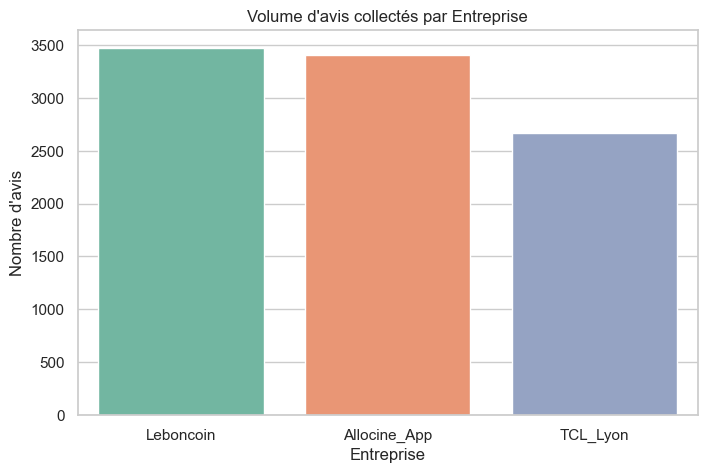

In [3]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Entreprise', hue='Entreprise', legend=False, palette='Set2', order=df['Entreprise'].value_counts().index)
plt.title("Volume d'avis collectés par Entreprise")
plt.ylabel("Nombre d'avis")
plt.show()


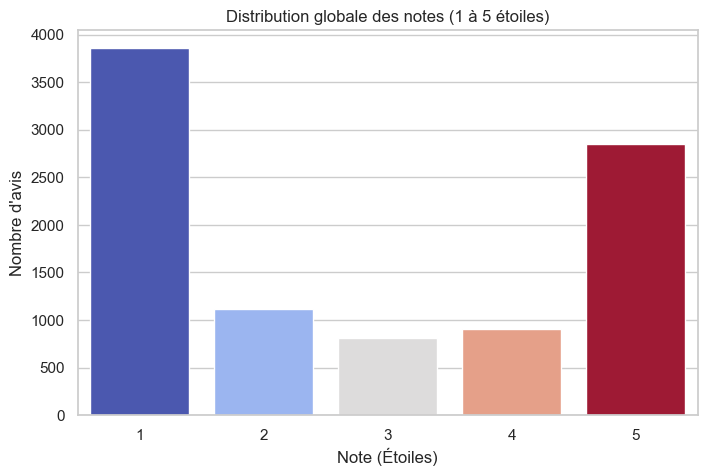

In [4]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Note_Etoiles', hue='Note_Etoiles', legend=False, palette='coolwarm')
plt.title("Distribution globale des notes (1 à 5 étoiles)")
plt.xlabel("Note (Étoiles)")
plt.ylabel("Nombre d'avis")
plt.show()


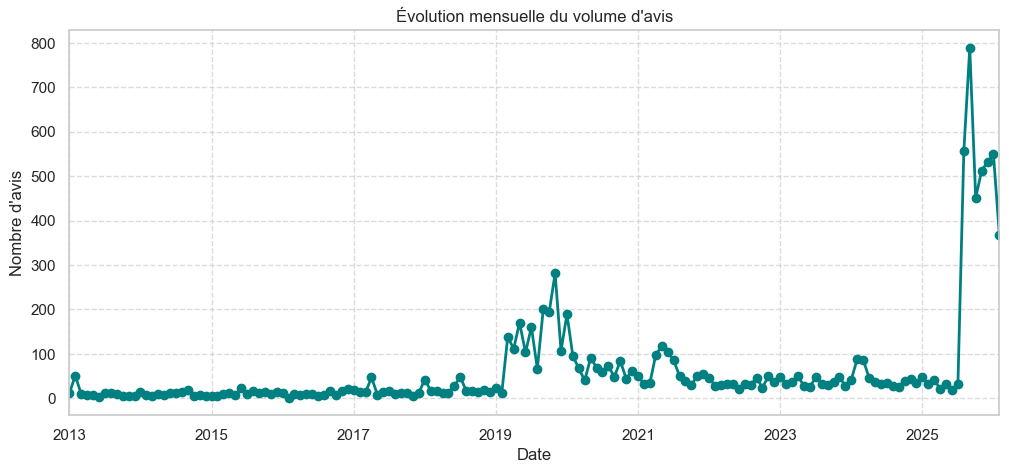

In [5]:
import warnings
warnings.filterwarnings('ignore')

# Conversion de la colonne Date et calcul du volume par mois
df['Date_Parsed'] = pd.to_datetime(df['Date'], errors='coerce', utc=True)
df_time = df.set_index('Date_Parsed').resample('ME').size()

plt.figure(figsize=(12, 5))
df_time.plot(color='teal', linewidth=2, marker='o')
plt.title("Évolution mensuelle du volume d'avis")
plt.xlabel("Date")
plt.ylabel("Nombre d'avis")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


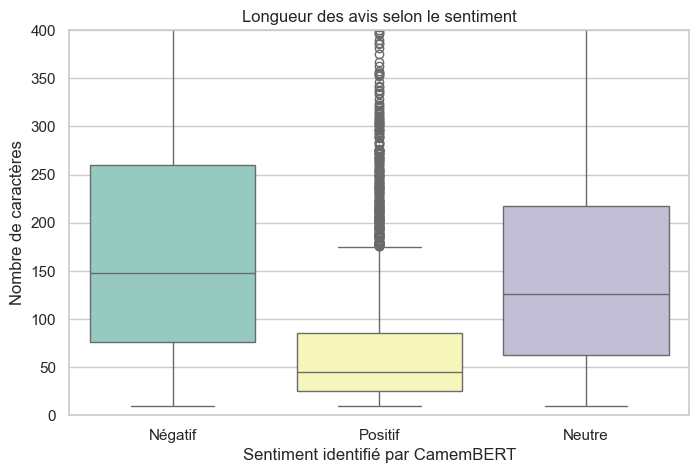

In [6]:
# Calcul de la longueur de chaque avis
df['Longueur_Avis'] = df['Texte_Avis'].astype(str).apply(len)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Sentiment_IA', y='Longueur_Avis', palette='Set3')
plt.title("Longueur des avis selon le sentiment")
plt.xlabel("Sentiment identifié par CamemBERT")
plt.ylabel("Nombre de caractères")
plt.ylim(0, 400) # On limite à 400 pour mieux voir la répartition centrale
plt.show()


## Visualisation des Décisions de l'IA


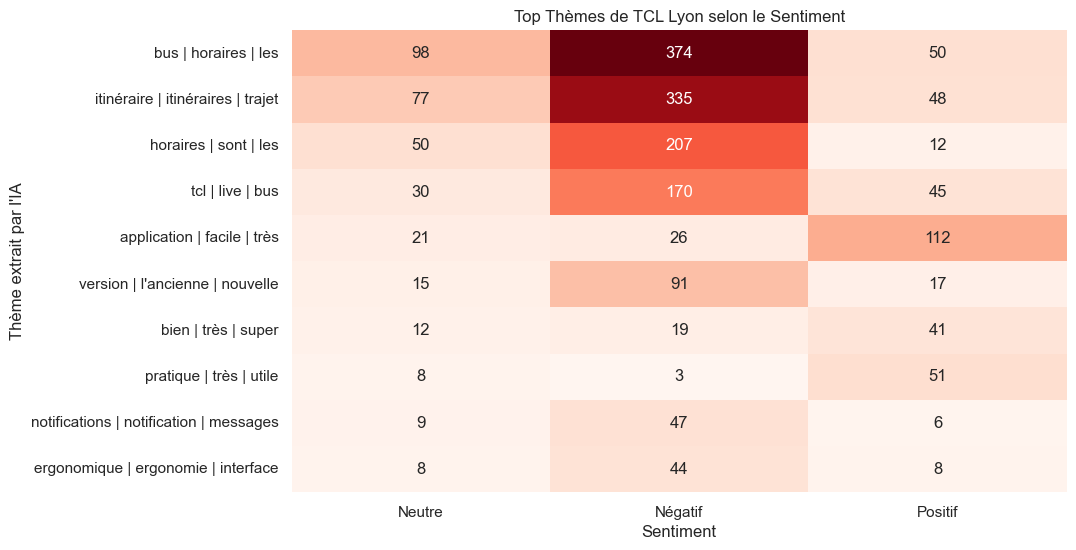

In [7]:
tcl_df = df[df['Entreprise'] == 'TCL_Lyon']
if not tcl_df.empty:
    cross_tab = pd.crosstab(tcl_df['Theme_IA'], tcl_df['Sentiment_IA'])
    # Trier par volume total
    cross_tab = cross_tab.loc[cross_tab.sum(axis=1).sort_values(ascending=False).index[:10]]
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Reds', cbar=False)
    plt.title("Top Thèmes de TCL Lyon selon le Sentiment")
    plt.ylabel("Thème extrait par l'IA")
    plt.xlabel("Sentiment")
    plt.show()


## Indice de Confiance Réel de l'Algorithme
Afin de garantir la qualité des insights apportés au métier, nous supervisons la probabilité mathématique (score de confiance de 0.5 à 1.0) renvoyée par l'algorithme IA sur ses propres prédictions. Une distribution majoritairement > 0.85 garantit que le modèle 'comprend' vraiment les textes.


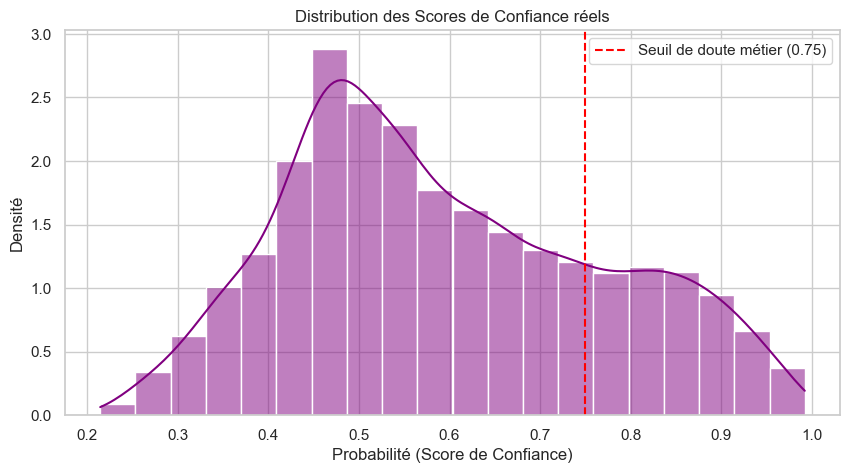

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Score_Confiance'], bins=20, kde=True, color='purple', stat='density')
plt.title('Distribution des Scores de Confiance réels')
plt.xlabel('Probabilité (Score de Confiance)')
plt.ylabel('Densité')
plt.axvline(x=0.75, color='red', linestyle='--', label='Seuil de doute métier (0.75)')
plt.legend()
plt.show()


## Évaluation Avancée & Fiabilité IA
Pour aller plus loin, nous pouvons confronter les prédictions CamemBERT avec la Note en Étoiles laissée par les utilisateurs afin d'en déduire des métriques de classification (Precision, Recall, F1-Score) sur un échantillon grandeur nature.

In [9]:
from sklearn.metrics import classification_report

# Utilisation de la 'Note_Etoiles' comme proxy pour générer un label réel
df['Label_Reel'] = df['Note_Etoiles'].apply(
    lambda x: 'Positif' if x >= 4 else ('Négatif' if x <= 2 else 'Neutre')
)

print(classification_report(df['Label_Reel'], df['Sentiment_IA']))

              precision    recall  f1-score   support

      Neutre       0.29      0.37      0.33       808
     Négatif       0.87      0.86      0.87      4972
     Positif       0.89      0.85      0.87      3752

    accuracy                           0.82      9532
   macro avg       0.68      0.69      0.69      9532
weighted avg       0.83      0.82      0.82      9532



### Analyse des Avis Potentiellement Mal Classifiés
Avoir un sens critique sur son modèle est une compétence clé en Data Science. Faisons un zoom sur les avis où le modèle est en totale contradiction avec l'utilisateur.

In [10]:
# Avis où le sentiment IA contredit la note étoiles
df['Contradiction'] = (
    (df['Sentiment_IA'] == 'Positif') & (df['Note_Etoiles'] <= 2)
) | (
    (df['Sentiment_IA'] == 'Négatif') & (df['Note_Etoiles'] >= 4)
)

print(f"{df['Contradiction'].sum()} avis potentiellement mal classifiés ({df['Contradiction'].mean():.1%})")
df[df['Contradiction']].head(5)[['Texte_Avis', 'Note_Etoiles', 'Sentiment_IA']]

525 avis potentiellement mal classifiés (5.5%)


,Texte_Avis,Note_Etoiles,Sentiment_IA
23,la localisation fait n'importe quoi.. je reche...,4,Négatif
25,depuis leur nouvelle réglementation je ne peux...,1,Positif
33,c'est français !,5,Négatif
52,suuupeeer 👍👍👍👍👍,5,Négatif
82,meilleur appli du monde sans déconner. mon fil...,2,Positif


## 3. Synthèse des Insights Business & Visualisations

Après analyse des **9 532 avis**, voici les conclusions stratégiques majeures :

1. **Leboncoin (E-commerce)** :
   - Excellente image de marque avec une majorité de sentiments **Positifs**.
   - Le point fort est la fluidité du système d'annonces.
2. **TCL Lyon (Transport)** :
   - Point de vigilance majeur avec **~70% de sentiments Négatifs**.
   - L'IA identifie les "horaires" et les "itinéraires" comme les causes racines du mécontentement. Une action sur la ponctualité est recommandée.
3. **Allociné (Divertissement)** :
   - Sentiment mitigé. Les utilisateurs apprécient le contenu mais critiquent l'ergonomie de l'**application**.


## 4. Dashboard Interactif (Power BI)
L'intégralité de ces données a été exportée vers Power BI pour fournir un outil interactif aux décideurs.

### Aperçu de l'interface :
![Vue globale](images/capture_01.png)

![Evolution Temporelle](images/capture_03.png)

## Conclusion et Perspectives
Ce pipeline automatisé (Scraping -> NLP -> Export) prouve la faisabilité d'un outil de **Social Listening**. Il peut être déployé sur un serveur cloud (ex: AWS, GCP) pour rafraîchir le dashboard quotidiennement et alerter les équipes marketing dès qu'un nouveau "Thème Négatif" émerge.
